In [ ]:
# 16 April 2025
# Zachary Katz
# zachary_katz@mines.edu

"""
Plot Figure 4, S3, S4 using output from Figure4.py saved as csv files in the output directory

"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage
import re
import ast


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs
import matplotlib.patheffects as pe
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
import geopandas as gpd
import matplotlib.colors as colors
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
from pyproj import CRS, Transformer

%matplotlib inline

In [2]:
# Set paths and make output directory
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
lake_path = '../_Data/Ju_SLD2'
outdir = './_OutputFigures'
csv_dir = './output750m_win_250m_ovlp'
evolving_path = '../_Data/Sauthoff_EvolvingOutlines'
DDInSAR_path = '../_Data/Kim_DDInSAR'
os.makedirs(outdir, exist_ok=True)

# Load KRT2 offset video netcdf files

file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1819[0]

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1617[0]


# Remove radargram.transect_id for x in ['X21b', 'X27b'] from offsert_video_radargrams_1819
offset_video_radargrams_1819 = [rg for rg in offset_video_radargrams_1819 if not any(x in rg.transect_id for x in ['X21a', 'X27a'])]

len(offset_video_radargrams_1819), len(offset_video_radargrams_1617)



(40, 11)

In [3]:
# Helper functions
def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y


In [4]:
# Load Subglacial Lake Cheongsuk shapefile
pathA = lake_path + '/SLD2-A.shp'
pathB = lake_path + '/SLD2-B.shp'
pathC = lake_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


In [5]:
# Convert from spatial freq width to doppler width
MS_TO_KMHR = 3.6
for radargram in offset_video_radargrams_1819[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt)

for radargram in offset_video_radargrams_1617[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt)

In [6]:
# Load csv files
def parse_floats(str_list):
    return [float(x) for x in re.findall(r'np\.float64\(([-0-9.eE]+)\)', str_list)]
def parse_arrays(str_list):
    return  [float(x) for x in re.findall(r'array\(([-0-9.eE]+)\)', str_list)]
def parse_ridge_params(str_list):
    str_list = re.sub(r'np\.float64\(([-0-9.eE]+)\)', r'\1', str_list)
    str_list = re.sub(r'np\.int64\(([-0-9]+)\)', r'\1', str_list)
    str_list = re.sub(r'\bnan\b', 'None', str_list)  
     
    return ast.literal_eval(str_list) # Careful with safe parsing

def none_to_nan(dictionary):
    # Recursively replace None with np.nan in dictionary/list
    if isinstance(dictionary, list):
        return [none_to_nan(x) for x in dictionary]

    elif isinstance(dictionary, dict):
        return {k: none_to_nan(v) for k, v in dictionary.items()}

    elif dictionary is None:
        return np.nan

    else:
        return dictionary

plotting_dict_1819_csv = pd.read_csv(os.path.join(csv_dir, 'plotting_dict_1819.csv'))
plotting_dict_1617_csv = pd.read_csv(os.path.join(csv_dir, 'plotting_dict_1617.csv'))

plotting_dict_1819_csv['x_centers'] = plotting_dict_1819_csv['x_centers'].apply(parse_floats)
plotting_dict_1819_csv['y_centers'] = plotting_dict_1819_csv['y_centers'].apply(parse_floats)
plotting_dict_1819_csv['ridge_params_list'] = plotting_dict_1819_csv['ridge_params_list'].apply(parse_ridge_params)
plotting_dict_1819_csv['velocities'] = plotting_dict_1819_csv['velocities'].apply(parse_arrays)

plotting_dict_1617_csv['x_centers'] = plotting_dict_1617_csv['x_centers'].apply(parse_floats)
plotting_dict_1617_csv['y_centers'] = plotting_dict_1617_csv['y_centers'].apply(parse_floats)
plotting_dict_1617_csv['ridge_params_list'] = plotting_dict_1617_csv['ridge_params_list'].apply(parse_ridge_params)
plotting_dict_1617_csv['velocities'] = plotting_dict_1617_csv['velocities'].apply(parse_arrays)

plotting_dict_1819_csv['ridge_params_list'] = plotting_dict_1819_csv['ridge_params_list'].apply(none_to_nan)
plotting_dict_1617_csv['ridge_params_list'] = plotting_dict_1617_csv['ridge_params_list'].apply(none_to_nan)

plotting_dict_1819 = plotting_dict_1819_csv.to_dict(orient='list')
plotting_dict = plotting_dict_1617_csv.to_dict(orient='list')


In [7]:
velocities_1819 = []
for radargram, center_list in zip(offset_video_radargrams_1819[:], plotting_dict_1819['x_centers'][:]):
    velocities = []
    for center in center_list[:]:
        idx = np.argmin(np.abs(radargram['x'].compute().values - center))
        velocities.append(radargram['velocity'][idx].values)
    
    velocities_1819.append(velocities)
  
velocities_1617 = []
for radargram, center_list in zip(offset_video_radargrams_1617[:], plotting_dict['x_centers'][:]):
    velocities = []
    for center in center_list[:]:
        idx = np.argmin(np.abs(radargram['x'].compute().values - center))
        velocities.append(radargram['velocity'][idx].values)
    
    velocities_1617.append(velocities)  

plotting_dict_1819['velocities'] = velocities_1819
plotting_dict['velocities'] = velocities_1617

In [8]:
# Plot difference

# Find points within 100 km of each other in the two datasets
coords_1819 = np.column_stack((
    np.concatenate(plotting_dict_1819['x_centers']),
    np.concatenate(plotting_dict_1819['y_centers'])
))

coords_1617 = np.column_stack((
    np.concatenate(plotting_dict['x_centers']),
    np.concatenate(plotting_dict['y_centers'])
))

ridge_params_1819 = [r for sublist in plotting_dict_1819['ridge_params_list'] for r in sublist]
ridge_params_1617 = [r for sublist in plotting_dict['ridge_params_list'] for r in sublist]

# Compute width (abs(left-right)) for each sub-point
width_1819 = np.array([abs(r['left'] - r['right']) for r in ridge_params_1819])
width_1617 = np.array([abs(r['left'] - r['right']) for r in ridge_params_1617])

# Compute scaled_width by multiplying by velocity
width_velocity_scaled_1819 = np.concatenate(velocities_1819) * width_1819
width_velocity_scaled_1617 = np.concatenate(velocities_1617) * width_1617

print(len(plotting_dict_1819['x_centers']))
print(len(plotting_dict_1819['y_centers']))
print(len(plotting_dict['x_centers']))
print(len(plotting_dict['y_centers']))
print(len(width_1819))
print(len(width_1617))
print(len(width_velocity_scaled_1819))
print(len(width_velocity_scaled_1617))

tree_1617 = cKDTree(coords_1617)

dist, idx = tree_1617.query(coords_1819)

mask = dist <= 500

matched_coords = coords_1819[mask]
ridge_diff = width_1819[mask] - width_1617[idx[mask]]
ridge_diff_velocity_scaled = width_velocity_scaled_1819[mask] - width_velocity_scaled_1617[idx[mask]]


40
40
11
11
2026
2675
2026
2675


In [9]:
# Crossover error with self
coords = []
width = []
width_velocity_corrected = []
line_id = []
y_at_max = []

all_velocities_1819 = np.concatenate(plotting_dict_1819['velocities'])
avg_velocity_1819 = np.mean(all_velocities_1819)

all_velocities_1617 = np.concatenate(plotting_dict['velocities'])
avg_velocity_1617 = np.mean(all_velocities_1617)

In [10]:
for i, (xs, ys, ridge_list, velocity) in enumerate(zip(
        plotting_dict_1819['x_centers'],
        plotting_dict_1819['y_centers'],
        plotting_dict_1819['ridge_params_list'],
        plotting_dict_1819['velocities'])):

    n = len(xs)

    

    coords.append(np.column_stack((xs, ys)))
    # Extend by the width of each ridge, scaled by velocity
    width_velocity_corrected.extend([abs(r['left'] - r['right']) * velocity[j] for j, r in enumerate(ridge_list)])
    #avg_velocity = np.mean(velocity)
    width.extend([abs(r['left'] - r['right'])*avg_velocity_1819 for r in ridge_list])
    line_id.extend([i]*n)
    y_at_max.extend([r['y_at_max'] for r in ridge_list])


coords = np.vstack(coords)
width = np.array(width)
width_velocity_corrected = np.array(width_velocity_corrected)
line_id = np.array(line_id)
y_at_max = np.array(y_at_max)

tree = cKDTree(coords)

pairs = np.array(list(tree.query_pairs(r=500)))

i, j = pairs[:,0], pairs[:,1]

mask = line_id[i] != line_id[j]

i = i[mask]
j = j[mask]

ridge_diff_1819 = np.abs(width[i] - width[j])
ridge_diff_velocity_corrected_1819 = np.abs(width_velocity_corrected[i] - width_velocity_corrected[j])
y_at_max = np.minimum(y_at_max[i], y_at_max[j])

coords_i = coords[i]
coords_j = coords[j]

x_cross_1819 = (coords[i,0] + coords[j,0]) / 2
y_cross_1819 = (coords[i,1] + coords[j,1]) / 2


mask = y_at_max > 1250
x_cross_1819 = x_cross_1819[mask]
y_cross_1819 = y_cross_1819[mask]
ridge_diff_velocity_corrected_1819 = ridge_diff_velocity_corrected_1819[mask]
ridge_diff_1819 = ridge_diff_1819[mask]

In [11]:
# Crossover error with self
coords = []
width = []
width_velocity_corrected = []
line_id = []
y_at_max = []

for i, (xs, ys, ridge_list, velocity) in enumerate(zip(
        plotting_dict['x_centers'],
        plotting_dict['y_centers'],
        plotting_dict['ridge_params_list'],
        plotting_dict['velocities'])):

    n = len(xs)

    coords.append(np.column_stack((xs, ys)))
    # Extend by the width of each ridge, scaled by velocity
    width_velocity_corrected.extend([abs(r['left'] - r['right']) * velocity[j] for j, r in enumerate(ridge_list)])
    avg_velocity = np.mean(velocity)
    width.extend([abs(r['left'] - r['right'])*avg_velocity_1617 for r in ridge_list])
    line_id.extend([i]*n)
    y_at_max.extend([r['y_at_max'] for r in ridge_list])

coords = np.vstack(coords)
width = np.array(width)
width_velocity_corrected = np.array(width_velocity_corrected)
line_id = np.array(line_id)
y_at_max = np.array(y_at_max)

tree = cKDTree(coords)

pairs = np.array(list(tree.query_pairs(r=500)))

i, j = pairs[:,0], pairs[:,1]

mask = line_id[i] != line_id[j]

i = i[mask]
j = j[mask]

ridge_diff_1617 = np.abs(width[i] - width[j])
ridge_diff_velocity_corrected_1617 = np.abs(width_velocity_corrected[i] - width_velocity_corrected[j])
y_at_max = np.minimum(y_at_max[i], y_at_max[j])

coords_i = coords[i]
coords_j = coords[j]

x_cross = (coords[i,0] + coords[j,0]) / 2
y_cross = (coords[i,1] + coords[j,1]) / 2

mask = y_at_max > 1250
x_cross = x_cross[mask]
y_cross = y_cross[mask]
ridge_diff_velocity_corrected_1617 = ridge_diff_velocity_corrected_1617[mask]
ridge_diff_1617 = ridge_diff_1617[mask]



In [12]:
### Figure 4 ###
# Doppler width map with velocity scaling for 2018-2019, 2016-2017, and difference map
# with comparison to satellite lake outlines

# Plot plan view comparison, scaled by velocity
def common_panel_elements(ax, plot_dict, rad_vel):
    """
    Plot doppler width and lake outline map view.
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot scaled widths
    for x_center_list, y_center_list, plotting, velocity in zip(plot_dict['x_centers'], plot_dict['y_centers'], plot_dict['ridge_params_list'], plot_dict['velocities']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        scaled_width = [w * v for w,v in zip(width,velocity)]  # Scale by velocity to get doppler width
        
        y_maxes = np.array([rp['y_at_max'] for rp in plotting])
        mask = y_maxes < 1250
        scaled_width = np.array([sw.item() for sw in scaled_width])
        scaled_width[mask] = np.nan
        
        cb = ax.scatter(x_center_list, y_center_list, c=scaled_width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=900)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )

    cbbox.set_facecolor([0,0,0,0.75])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label(r"Doppler Width [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    
    scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
    ax.add_artist(scalebar)

    # Glacial flow arrow
    ax.annotate(
    '',
    xy=(659000, -1436000),      # Tip
    xytext=(664000, -1431000),  # Tail
    arrowprops=dict(
        arrowstyle='-|>',       
        color='black',
        lw=2,
        mutation_scale=20 ,     
    ),
    transform=ps71_projection,
    zorder=10
    )
    ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

    return ax


# Load evolving outlines
evolving_outlines = gpd.read_file(f'{evolving_path}/David_s1.geojson')

# Load DDInSAR outlines
path2 = f'{DDInSAR_path}/David2.shp'
path2_1 = f'{DDInSAR_path}/David2-1.shp'

DDInSAR_outlines = []
for path in [path2, path2_1]:
    sf = shapefile.Reader(path)
    for shape in sf.shapes():
        points = shape.points
        pts_xy = ll2xy([p[0] for p in points], [p[1] for p in points])
        x, y = pts_xy

        DDInSAR_outlines.append((x, y))


In [13]:
times = evolving_outlines["mid_pt_datetime"]
# Find index of time closest to Jan 25 2017 and Nov 20 2018
target_time_1617 = np.datetime64('2017-01-25T00:00:00')
target_time_1819 = np.datetime64('2018-11-20T00:00:00')

idx_1617 = np.argmin(np.abs(times - target_time_1617))
idx_1819 = np.argmin(np.abs(times - target_time_1819))
print(times[idx_1617], times[idx_1819])

# Plot outlines function
def plot_outlines(ax, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819):
    """Plot outlines for radar, DDInSAR, and Altimetry. Return colors associated with each"""
    colors = []
    # Plot evolving outlines
    for index in [idx_1617, idx_1819]:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    # Plot DDInSAR outlines
    color_DDInSAR = 'black'
    for i, (x, y) in enumerate(DDInSAR_outlines):
        ax.plot(x, y, color=color_DDInSAR, linewidth=2.5, zorder=5)
    colors.append(color_DDInSAR)

    # Plot radar outlines
    color_radar = 'white'
    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color=color_radar, linewidth=2.5, zorder=5)
    colors.append(color_radar)
    
    # Label radar lakes A, B, C
    ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
    ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
    ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

    return colors


2017-01-01 00:00:00 2019-01-01 00:00:00


/tmp/ipykernel_59389/2043041526.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


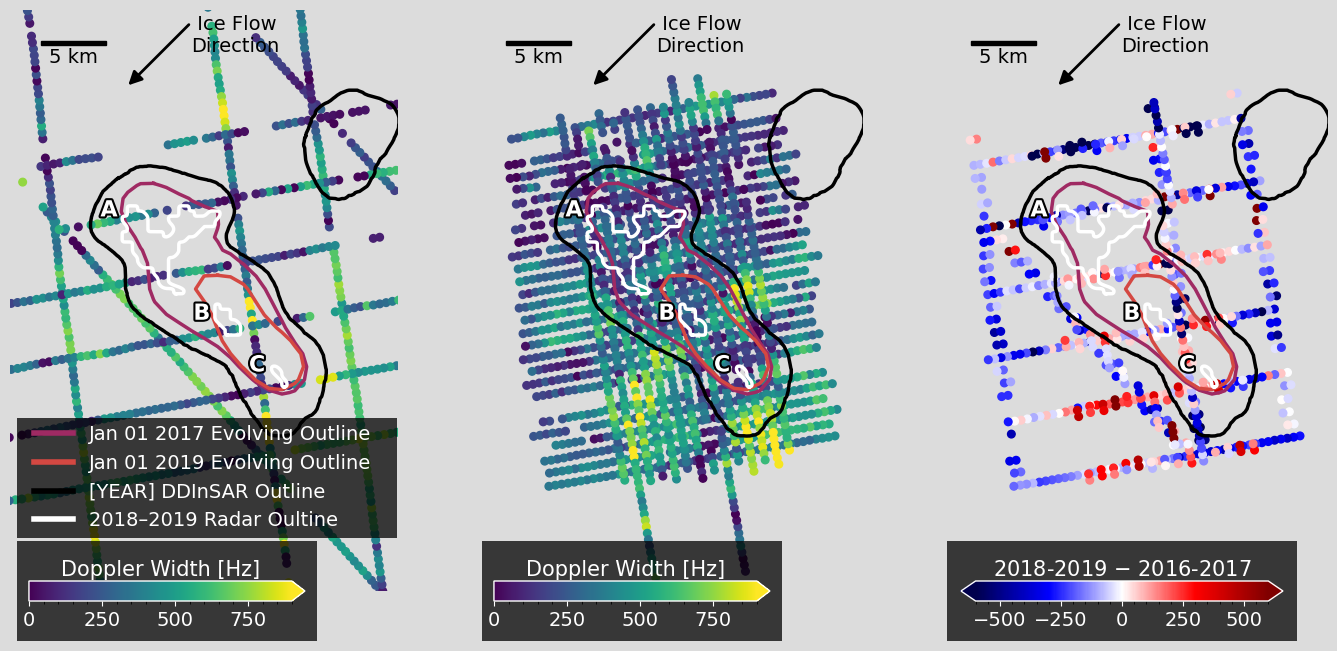

In [17]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, axs = plt.subplots(1,3, figsize=(17,8), subplot_kw={'projection': ps71_projection})
(ax1, ax2, ax3) = axs.flatten()

# Convert datetimes → numeric (float seconds)
t_num = np.array(times.astype("int64"))  # nanoseconds since epoch

# Normalize to 0–1 range for the colormap
norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
cmap = cm.get_cmap("inferno")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)


## AX1 ##
common_panel_elements(ax1, plotting_dict, offset_video_radargrams_1617)
colors_plotted = plot_outlines(ax1, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819)

k_cbar_anchor = (0,0.08) # Bottom right of ax1
cbbox = inset_axes(ax1, width=3.8,height=1.2,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax1.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.75])
handles = [
    Line2D([0], [0], color=colors_plotted[0], lw=4, label='Jan 01 2017 Evolving Outline'),
    Line2D([0], [0], color=colors_plotted[1], lw=4, label='Jan 01 2019 Evolving Outline'),
    Line2D([0], [0], color=colors_plotted[2], lw=4, label='[YEAR] DDInSAR Outline'),
    Line2D([0], [0], color=colors_plotted[3], lw=4, label='2018\u20132019 Radar Oultine'),
]

# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')




## AX2 ##
common_panel_elements(ax2, plotting_dict_1819, offset_video_radargrams_1819)
plot_outlines(ax2, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819)


## AX3 ##
# Remove borders
ax3.patch.set_facecolor("none")
for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.set_xticks([])
ax3.set_yticks([])


# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax3, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax3.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.75])

cb = ax3.scatter(matched_coords[:,0], matched_coords[:,1], c=ridge_diff_velocity_scaled, cmap='seismic', s=30, zorder=4,vmin=-600,vmax=600)
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='both') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"2018-2019 $-$ 2016-2017", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

scalebar = AnchoredSizeBar(ax3.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax3.add_artist(scalebar)

# Glacial flow arrow
ax3.annotate(
'',
xy=(659000, -1436000),      # Tip
xytext=(664000, -1431000),  # Tail
arrowprops=dict(
    arrowstyle='-|>',       
    color='black',
    lw=2,
    mutation_scale=20 ,     
),
transform=ps71_projection,
zorder=10
)
ax3.text(664000, -1432000, ' Ice Flow\nDirection',
    fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
ax3.set_xlim(bbox[0],bbox[2])
ax3.set_ylim(bbox[1],bbox[3])

plot_outlines(ax3, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819)

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'Figure4.png'), dpi=300, bbox_inches='tight')



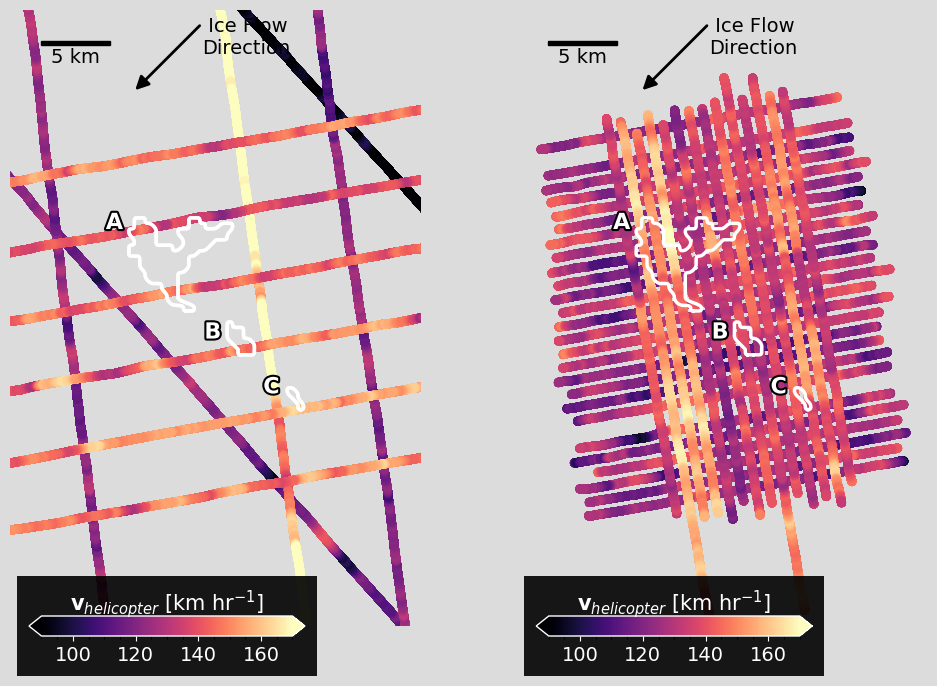

In [15]:
## Figure S3 ##
# Velocity plots

# Plot velocities
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, (ax,ax2) = plt.subplots(1,2,figsize=(12,8), subplot_kw={'projection': ps71_projection})

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax, width=3,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

for radargram in offset_video_radargrams_1617[:]:
    #if 'Y' in radargram.transect_id.split('/')[-1]:
    cb = ax.scatter(radargram['x'],radargram['y'] , c=radargram['velocity'] * MS_TO_KMHR, cmap='magma', s=30, zorder=4,vmin=90,vmax=170)
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='both') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{helicopter}$ [km hr$^{-1}$]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)


# Label lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Ax2
scalebar = AnchoredSizeBar(ax2.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax2.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax2.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax2.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

# Remove borders
ax2.patch.set_facecolor("none")
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])

for x, y in zip(xs_lake, ys_lake):
    ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax2, width=3,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax2.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])

for radargram in offset_video_radargrams_1819[:]:
    #if 'Y' in radargram.transect_id.split('/')[-1]:
    cb = ax2.scatter(radargram['x'],radargram['y'] , c=radargram['velocity'] * MS_TO_KMHR, cmap='magma', s=30, zorder=4,vmin=90,vmax=170)
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal', extend='both') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{helicopter}$ [km hr$^{-1}$]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

ax2.set_xlim(bbox[0],bbox[2])
ax2.set_ylim(bbox[1],bbox[3])
#ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

for x, y in zip(xs_lake, ys_lake):
    ax2.plot(x, y, color='white', linewidth=2.5, zorder=5)

# Label lakes A, B, C
ax2.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax2.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax2.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'FigureS3.png'), dpi=300, bbox_inches='tight')

972 972 972 972


/tmp/ipykernel_59389/2734206991.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


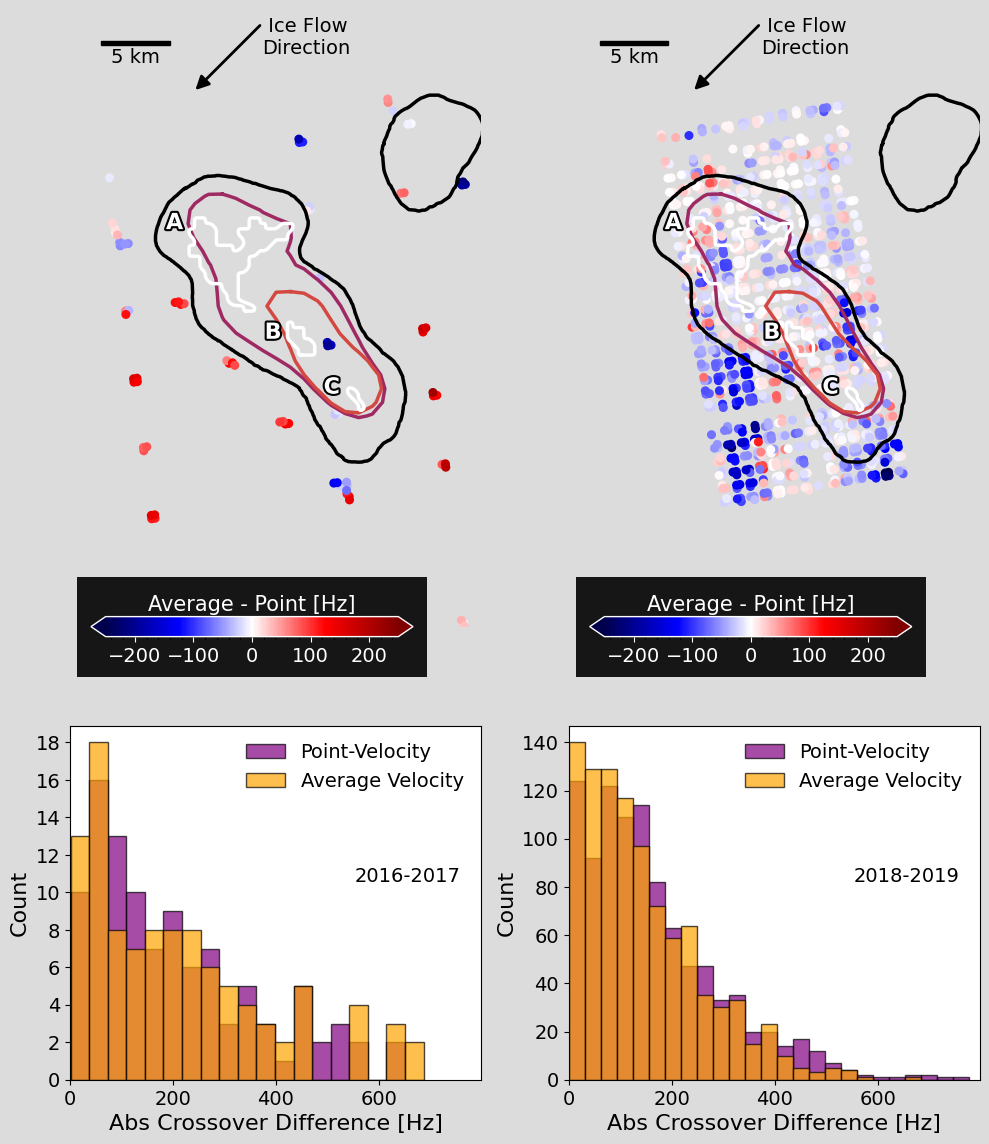

In [16]:
## Figure S4 ##
def common_panel_elements_S3(ax, plot_dict, rad_vel):
    """
    Plot doppler width and lake outline map view.
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    
    scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
    ax.add_artist(scalebar)

    # Glacial flow arrow
    ax.annotate(
    '',
    xy=(659000, -1436000),      # Tip
    xytext=(664000, -1431000),  # Tail
    arrowprops=dict(
        arrowstyle='-|>',       
        color='black',
        lw=2,
        mutation_scale=20 ,     
    ),
    transform=ps71_projection,
    zorder=10
    )
    ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

    return ax

# Two histograms, 2016-2017 and 2018-2019 next to double difference plots
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(2, 2,height_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, 0], projection=ps71_projection)
ax2 = fig.add_subplot(gs[0, 1], projection=ps71_projection)
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Maps
common_panel_elements_S3(ax1, plotting_dict, offset_video_radargrams_1617)
plot_outlines(ax1, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819)
cb = ax1.scatter(x_cross, y_cross, c=ridge_diff_1617-ridge_diff_velocity_corrected_1617, cmap='seismic', s=30, zorder=4,vmin=-250,vmax=250) 


common_panel_elements_S3(ax2, plotting_dict_1819, offset_video_radargrams_1819)
plot_outlines(ax2, evolving_outlines, DDInSAR_outlines, idx_1617, idx_1819)
print(len(x_cross_1819), len(y_cross_1819), len(ridge_diff_1819), len(ridge_diff_velocity_corrected_1819))
cb = ax2.scatter(x_cross_1819, y_cross_1819, c=ridge_diff_1819-ridge_diff_velocity_corrected_1819, cmap='seismic', s=30, zorder=4,vmin=-250,vmax=250)

fig.set_facecolor('gainsboro')

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax1, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax1.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal', extend='both') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label("Average - Point [Hz]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

# Add colorbar
k_cbar_anchor = (0,0)
cbbox = inset_axes(ax2, width=3.5,height=1,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax2.transAxes, loc="center left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.9])
cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='both') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label("Average - Point [Hz]", fontsize=15, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()






# Histograms
# Combine data to get common bins
all_data = np.concatenate([ridge_diff_velocity_corrected_1617, ridge_diff_1617])
bins = np.linspace(all_data.min(), all_data.max(), 20) 

ax3.hist(ridge_diff_velocity_corrected_1617, bins=bins, color='purple',alpha=0.7, edgecolor='black')
ax3.hist(ridge_diff_1617, bins=bins, color='orange',alpha=0.7, edgecolor='black')
# Boxplot
#ax.boxplot(abs_ridge_diff, vert=False, patch_artist=True, boxprops=dict(facecolor='purple', color='black'), medianprops=dict(color='yellow'))
ax3.set_xlabel('Abs Crossover Difference [Hz]', fontsize=16)
ax3.set_ylabel('Count', fontsize=16)
ax3.tick_params(labelsize=14)
ax3.text(0.95, 0.6, f'2016-2017', transform=ax3.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right')

ax3.legend(['Point-Velocity', 'Average Velocity'], fontsize=14, loc='upper right', frameon=False)
ax3.set_xlim(0, 799)
ax3.set_yticks(np.arange(0, 20, 2))

# Combine data to get common bins
all_data = np.concatenate([ridge_diff_velocity_corrected_1819, ridge_diff_1819])
bins = np.linspace(all_data.min(), all_data.max(), 26) 

ax4.hist(ridge_diff_velocity_corrected_1819, bins=bins, color='purple',alpha=0.7, edgecolor='black')
ax4.hist(ridge_diff_1819, bins=bins, color='orange',alpha=0.7, edgecolor='black')
# Boxplot
#ax.boxplot(abs_ridge_diff, vert=False, patch_artist=True, boxprops=dict(facecolor='purple', color='black'), medianprops=dict(color='yellow'))
ax4.set_xlabel('Abs Crossover Difference [Hz]', fontsize=16)
ax4.set_ylabel('Count', fontsize=16)
ax4.tick_params(labelsize=14)
ax4.set_xlim(0, 799)
ax4.text(0.95, 0.6, f'2018-2019', transform=ax4.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right')

ax4.legend(['Point-Velocity', 'Average Velocity'], fontsize=14, loc='upper right', frameon=False)

# Pad bottom row for y axis labels
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
fig.savefig(os.path.join(outdir, 'FigureS4.png'), dpi=300, bbox_inches='tight')